<a href="https://colab.research.google.com/github/farrelandika/PCVK_Genap_2021/blob/main/Pertemuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()  # akan muncul dialog pilih file

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Replace 'path/to/your/data.csv' with the actual path to your file in Google Drive
file_path = '/content/drive/MyDrive/path/to/your/data.csv'

# Example: if your data is a CSV file, you can load it with pandas
import pandas as pd
df = pd.read_csv(file_path)
display(df.head())

In [ ]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # untuk menampilkan image di Colab
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

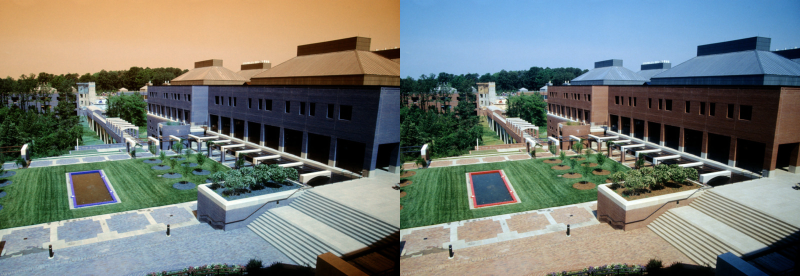

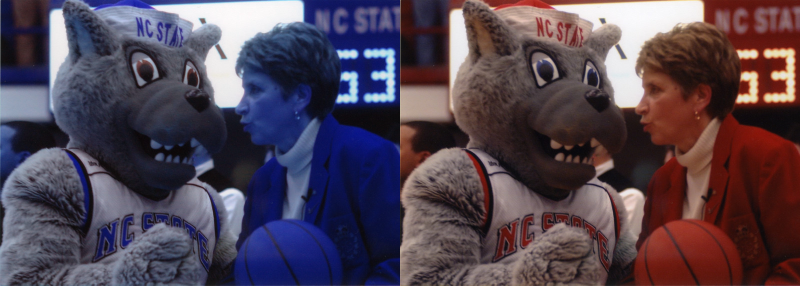

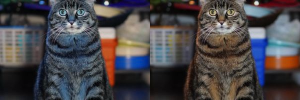

In [ ]:
# Membuat list untuk menyimpan url dari beberapa image
urls = ["https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
        "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
        "https://placecats.com/300/200"]

# baca dan tampilkan image
# loop pada tiap url image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                              # read image
    image = cv.resize(image, (0,0), fx=0.5, fy=0.5)      # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)       # convert color to RGB
    final_frame = cv.hconcat((image, image_2))           # concatenate image
    cv2_imshow(final_frame)                              # show image
    print('\n')

Resolusi image : tinggi x lebar =  100  x  150


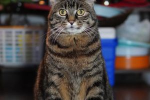

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("Resolusi image : tinggi x lebar = " , tinggi, " x " , lebar)
cv2_imshow(image_2)

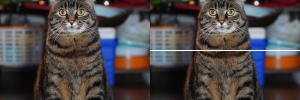

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# membuat garis horizontal di tengah image
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

In [ ]:
#PERTANYAAN PRAKTIKUM D2
1. Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan
menggunakan Google Colab?
2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke
delapan? Apakah semua library tersebut harus digunakan dalam praktikum
sesi ini?
3. Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut :
Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak
dilakukan?
4. Perhatikan potongan kode progam berikut :
Apakah kegunaan kode [255,255,255] ? Jelaskan!
5. Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun
rendah

#JAWABAN
1. Karena google colab memiliki banyak keunggulan, yaitu beberapa mencakup berbasis
cloud dan gratis, dapat terintegrasi dengan github dan google drive, dan dapat diakses
dengan mudah.

2. Kegunaan setiap library pada
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt
a. yaitu untuk Numpy sendiri, untuk Manipulasi array numerik
 (operasi vektor/matriks), dasar representasi citra sebagai array.
b. pandas yaitu Manipulasi dan analisis data tabular
 (tidak selalu untuk citra langsung)
c. cv2 (OpenCV)	Pengolahan citra utama: baca, tampilkan, transformasi,
deteksi objek
d. cv2_imshow	Fungsi khusus untuk menampilkan image di lingkungan Google
Colab (karena cv2.imshow() biasa tidak berjalan di Colab)
e. skimage (io)	Membaca citra, termasuk dari URL
f. skimage (transform)	Fungsi transformasi citra
tingkat lanjut (resize, rotate, dll.)
g. PIL (Image)	Library alternatif untuk membuka dan memanipulasi citra
h. Matplotlib	Visualisasi/plotting citra beserta informasi sumbu (ukuran piksel)

3. kode cv.resize(image, (0,0), fx=0.5, fy=0.5) digunakan untuk mengubah ukuran
 (resize) citra menjadi setengah dari ukuran aslinya, dengan parameter:
(0,0) → ukuran tujuan tidak ditentukan secara eksplisit dalam piksel
fx=0.5 → skala lebar menjadi 50% dari ukuran asli
fy=0.5 → skala tinggi menjadi 50% dari ukuran asli
Jika tidak dilakukan: citra akan tetap tampil dalam ukuran aslinya
(bisa jadi cukup besar, misalnya 800px), sehingga saat digabungkan (hconcat)
dengan citra lain untuk ditampilkan berdampingan,
ukurannya menjadi lebih besar/berat dan bisa memenuhi
tampilan output tanpa efisiensi ruang.

4. Kegunaan kode [255, 255, 255] pada:
for y in range(lebar):
    image_3[int(tinggi/2), y] = [255, 255, 255]
yaitu agar nilai rgb menjadi warna
putih kertas

5. Untuk pixel sendiri yaitu adalah unit terkecil penyusun sebuah citra digital
yang mana seetiap pixel memiliki nilai intensitas berupa greyscale atau true color
(RGB) sedangkan untuk resolusi sendiri adalah jumlah pixel yang menyusun citra dalam
dimensi vertikal x horizontal contohnya yaitu 1920x1080

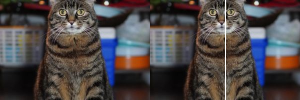

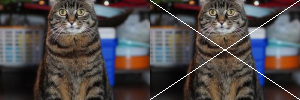

In [ ]:
#Tugas Praktikum D2
# 2. Membuat Garis Vertikal dan Garis Menyilang Diagonal
image_vertikal = image_2.copy()

# Garis Vertikal di tengah image
for x in range(tinggi):
    image_vertikal[x, int(lebar/2)] = [255, 255, 255]

# Garis Diagonal Menyilang
image_diagonal = image_2.copy()

cv.line(image_diagonal, pt1=(0, 0), pt2=(lebar-1, tinggi-1), color=(255, 255, 255), thickness=1)
cv.line(image_diagonal, pt1=(lebar-1, 0), pt2=(0, tinggi-1), color=(255, 255, 255), thickness=1)

# gabungkan image asli dengan hasil garis vertikal + diagonal
final_frame = cv.hconcat((image_2, image_vertikal))
final_frame2 = cv.hconcat((image_2, image_diagonal))

cv2_imshow(final_frame)
print('\n')
cv2_imshow(final_frame2)

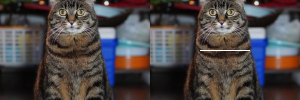

In [ ]:
# 3. Membuat Garis Horizontal Berwarna Putih dengan Panjang Tertentu
image_horizontal = image_2.copy()

# tentukan panjang garis yang diinginkan (misal 50 pixel, mulai dari tengah)
panjang_garis = 50
mulai_x = int((lebar - panjang_garis) / 2)   # posisi awal garis (biar di tengah)
y_tengah = int(tinggi / 2)

for x in range(mulai_x, mulai_x + panjang_garis):
    image_horizontal[y_tengah, x] = [255, 255, 255]

final_frame3 = cv.hconcat((image_2, image_horizontal))
cv2_imshow(final_frame3)

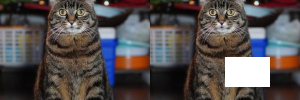

In [ ]:
# 4. Membuat Kotak Menggunakan Kumpulan Pixel Warna Putih
import random # Import modul random untuk posisi acak

gambar_kotak = image_2.copy()

# Tentukan ukuran kotak (misalnya, 30% dari tinggi dan lebar gambar)
tinggi_kotak = int(tinggi * 0.3)
lebar_kotak = int(lebar * 0.3)

# Tentukan posisi awal kotak secara acak, pastikan tidak keluar batas gambar
baris_awal = random.randint(0, tinggi - tinggi_kotak - 1)
kolom_awal = random.randint(0, lebar - lebar_kotak - 1)

baris_akhir = baris_awal + tinggi_kotak
kolom_akhir = kolom_awal + lebar_kotak

for baris in range(baris_awal, baris_akhir):
    for kolom in range(kolom_awal, kolom_akhir):
        gambar_kotak[baris, kolom] = [255, 255, 255] # Mengatur piksel menjadi putih

bingkai_akhir_4 = cv.hconcat((image_2, gambar_kotak))
cv2_imshow(bingkai_akhir_4)

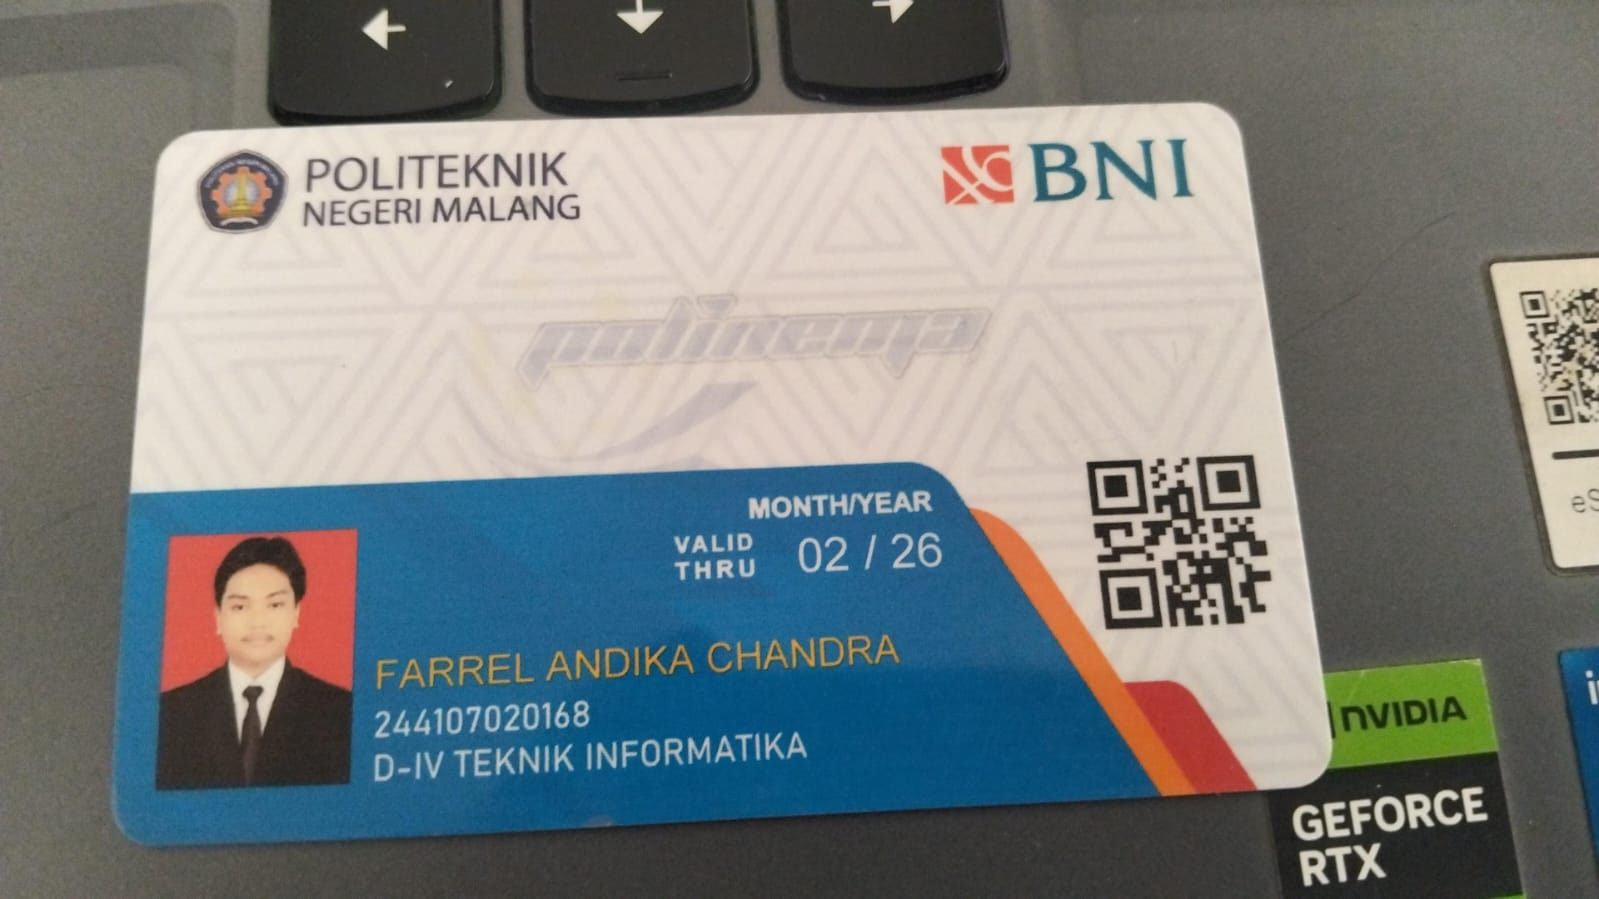

Resolusi gambar: 1599 x 899


In [30]:
# D3. Pengenalan Python: Pengolahan Citra Dasar dan memahami channel warna pada OpenCV dan konversinya
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
cv2_imshow(img)

print("Resolusi gambar:", img.shape[1], "x", img.shape[0])

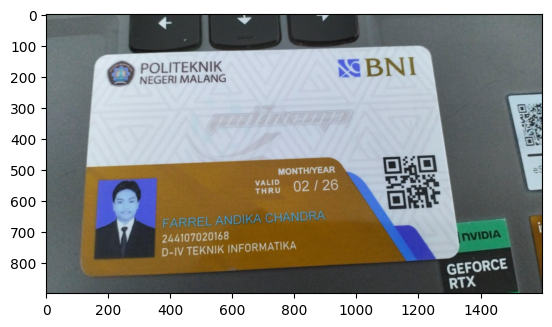

In [ ]:
# Menampilkan Gambar dengan matplotlib
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
plt.imshow(img) #Format waena BGR

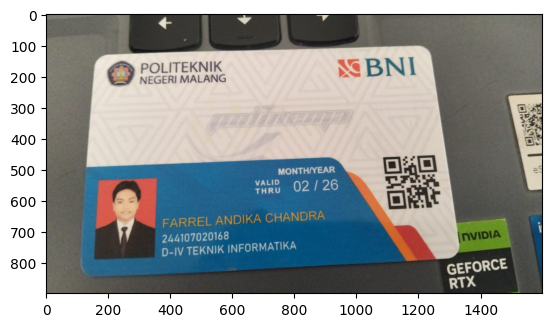

In [29]:
# Konversi BGR → RGB:
img = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg")
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Konversi BGR ke RGB
plt.imshow(img2)

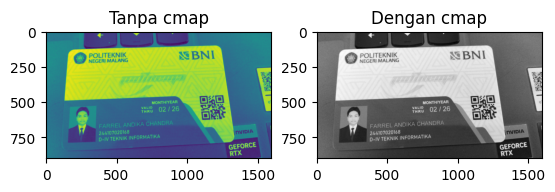

In [28]:
# Langkah 3_Menampilkan Citra Grayscale
img_gray = cv2.imread("/content/drive/MyDrive/PCVK/WhatsApp Image 2026-09-01 at 4.54.04 PM.jpeg", cv2.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("Tanpa cmap")

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap="gray")
plt.title("Dengan cmap")

plt.show()